In [6]:
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

from imblearn.over_sampling import SMOTE

In [7]:
df = pd.read_csv("titanic.csv")

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


In [9]:
print("Shape :", df.shape)

print()

print(df.info())

Shape : (889, 14)

<class 'pandas.DataFrame'>
RangeIndex: 889 entries, 0 to 888
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     889 non-null    int64  
 1   pclass       889 non-null    int64  
 2   sex          889 non-null    str    
 3   age          889 non-null    float64
 4   sibsp        889 non-null    int64  
 5   parch        889 non-null    int64  
 6   fare         889 non-null    float64
 7   embarked     889 non-null    str    
 8   class        889 non-null    str    
 9   who          889 non-null    str    
 10  adult_male   889 non-null    bool   
 11  embark_town  889 non-null    str    
 12  alive        889 non-null    str    
 13  alone        889 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(6)
memory usage: 85.2 KB
None


In [10]:
features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked"
]

X = df[features]

y = df["survived"]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print("Training :", X_train.shape)

print("Testing :", X_test.shape)

Training : (711, 7)
Testing : (178, 7)


In [12]:
numeric_features = [
    "age",
    "fare",
    "sibsp",
    "parch",
    "pclass"
]

categorical_features = [
    "sex",
    "embarked"
]

In [13]:
numeric_transformer = Pipeline(

    steps=[

        (
            "imputer",
            SimpleImputer(strategy="median")
        ),

        (
            "scaler",
            StandardScaler()
        )

    ]

)

In [14]:
categorical_transformer = Pipeline(

    steps=[

        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),

        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )

    ]

)

In [15]:
preprocessor = ColumnTransformer(

    transformers=[

        (

            "numeric",

            numeric_transformer,

            numeric_features

        ),

        (

            "categorical",

            categorical_transformer,

            categorical_features

        )

    ]

)

In [16]:
logistic_model = Pipeline(

    steps=[

        (
            "preprocessor",
            preprocessor
        ),

        (
            "classifier",
            LogisticRegression(
                random_state=42,
                max_iter=1000
            )
        )

    ]

)

decision_tree = Pipeline(

    steps=[

        (
            "preprocessor",
            preprocessor
        ),

        (
            "classifier",
            DecisionTreeClassifier(
                random_state=42
            )
        )

    ]

)

random_forest = Pipeline(

    steps=[

        (
            "preprocessor",
            preprocessor
        ),

        (
            "classifier",
            RandomForestClassifier(
                random_state=42,
                oob_score=True
            )
        )

    ]

)

In [17]:
models = {

    "Logistic Regression": logistic_model,

    "Decision Tree": decision_tree,

    "Random Forest": random_forest

}

for name, model in models.items():

    print(f"Training {name}...")

    model.fit(
        X_train,
        y_train
    )

print()

print("All Models Trained Successfully!")

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...

All Models Trained Successfully!


In [18]:
def evaluate_model(model, X_test, y_test):

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    return {
        "Prediction": y_pred,
        "Probability": y_prob,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "AUC": auc
    }

In [19]:
results = {}

for name, model in models.items():

    print(f"Evaluating {name}...")

    results[name] = evaluate_model(
        model,
        X_test,
        y_test
    )

print("\nEvaluation Completed!")

Evaluating Logistic Regression...
Evaluating Decision Tree...
Evaluating Random Forest...

Evaluation Completed!


In [20]:
comparison = pd.DataFrame({

    "Model": results.keys(),

    "Accuracy": [results[m]["Accuracy"] for m in results],

    "Precision": [results[m]["Precision"] for m in results],

    "Recall": [results[m]["Recall"] for m in results],

    "F1 Score": [results[m]["F1 Score"] for m in results],

    "ROC-AUC": [results[m]["AUC"] for m in results]

})

comparison = comparison.sort_values(
    by="Accuracy",
    ascending=False
)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Random Forest,0.820225,0.781250,0.735294,0.757576,0.821457
0,Logistic Regression,0.808989,0.783333,0.691176,0.734375,0.860963
1,Decision Tree,0.769663,0.690141,0.720588,0.705036,0.754144


In [21]:
best_model_name = comparison.iloc[0]["Model"]

print("Best Model :", best_model_name)

Best Model : Random Forest


In [22]:
def plot_confusion(model_name):

    cm = confusion_matrix(
        y_test,
        results[model_name]["Prediction"]
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm
    )

    disp.plot(cmap="Blues")

    plt.title(f"{model_name} Confusion Matrix")

    plt.show()

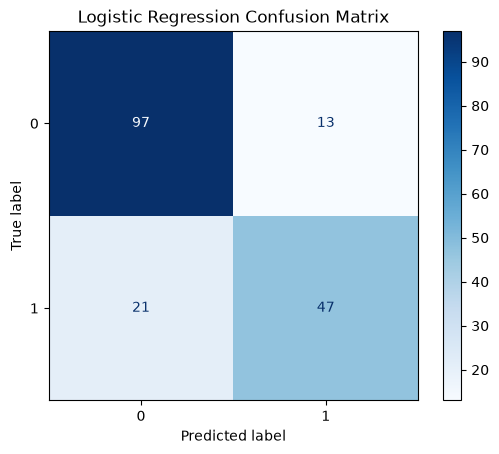

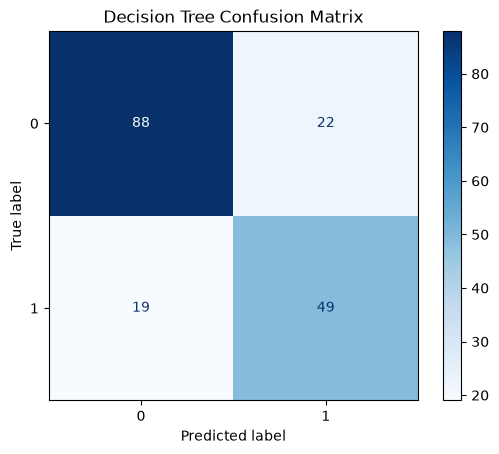

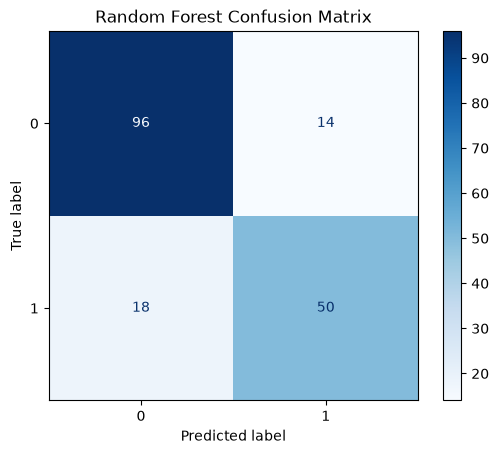

In [23]:
for model_name in models.keys():

    plot_confusion(model_name)

In [24]:
def plot_roc(model_name):

    fpr, tpr, _ = roc_curve(

        y_test,

        results[model_name]["Probability"]

    )

    plt.figure(figsize=(6,5))

    plt.plot(
        fpr,
        tpr,
        label=f"AUC = {results[model_name]['AUC']:.3f}"
    )

    plt.plot([0,1],[0,1],"k--")

    plt.xlabel("False Positive Rate")

    plt.ylabel("True Positive Rate")

    plt.title(f"{model_name} ROC Curve")

    plt.legend()

    plt.show()

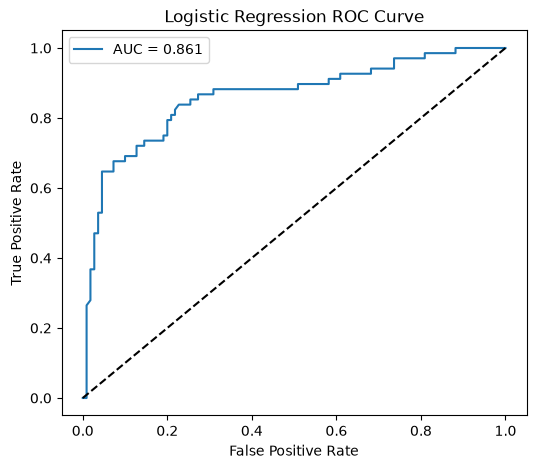

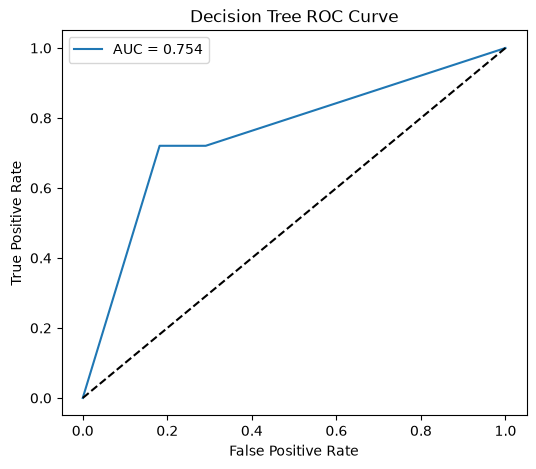

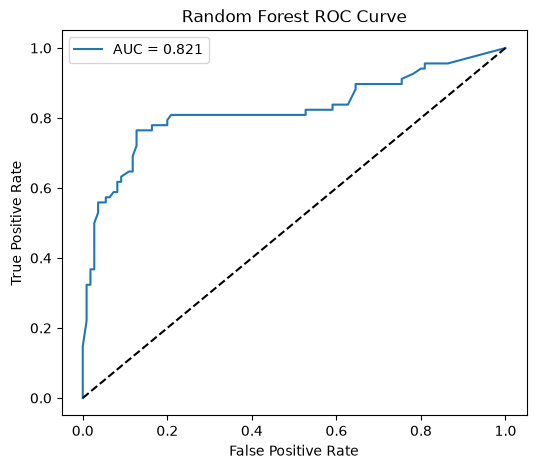

In [25]:
for model_name in models.keys():

    plot_roc(model_name)

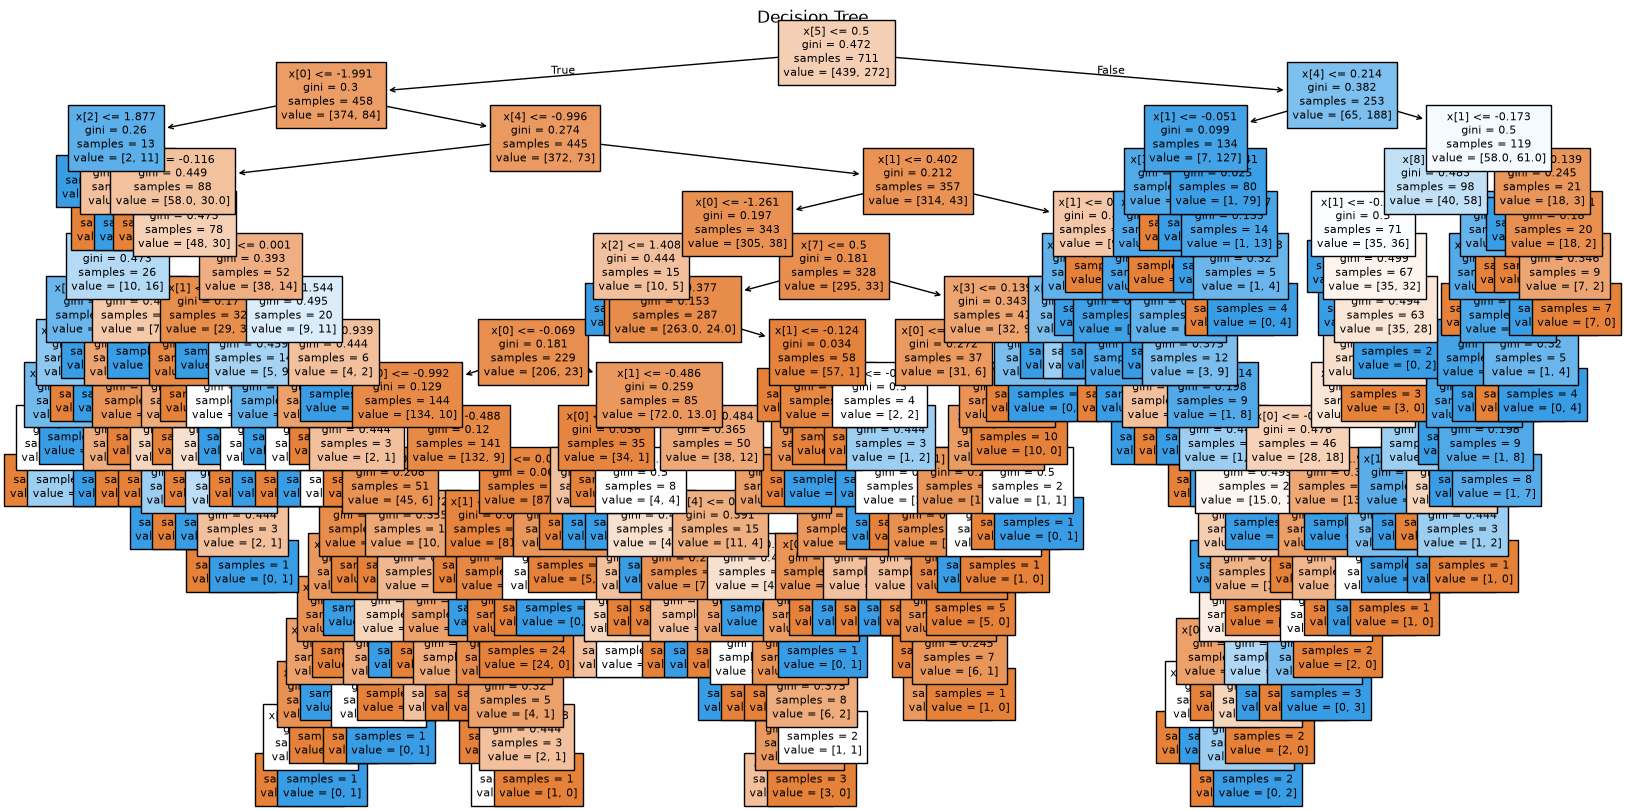

In [26]:
tree_model = decision_tree.named_steps["classifier"]

plt.figure(figsize=(20,10))

plot_tree(
    tree_model,
    filled=True,
    fontsize=8
)

plt.title("Decision Tree")

plt.show()

Class Distribution:
survived
0    439
1    272
Name: count, dtype: int64


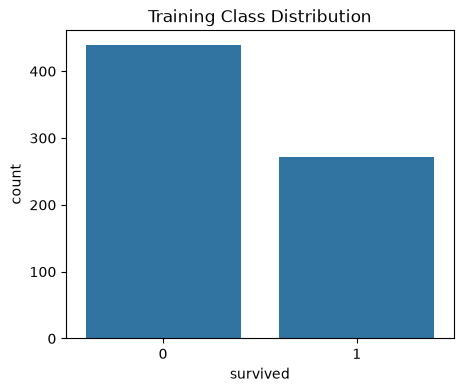

In [27]:
print("Class Distribution:")

print(y_train.value_counts())

plt.figure(figsize=(5,4))

sns.countplot(x=y_train)

plt.title("Training Class Distribution")

plt.show()

In [28]:
balanced_logistic = Pipeline(

    steps=[

        ("preprocessor", preprocessor),

        ("classifier",
         LogisticRegression(
             class_weight="balanced",
             random_state=42,
             max_iter=1000
         ))

    ]

)

balanced_logistic.fit(X_train, y_train)

balanced_result = evaluate_model(
    balanced_logistic,
    X_test,
    y_test
)

print("Balanced Logistic Accuracy:",
      balanced_result["Accuracy"])

Balanced Logistic Accuracy: 0.7921348314606742


In [29]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

print("Before SMOTE")

print(y_train.value_counts())

print()

print("After SMOTE")

print(pd.Series(y_train_smote).value_counts())

Before SMOTE
survived
0    439
1    272
Name: count, dtype: int64

After SMOTE
survived
1    439
0    439
Name: count, dtype: int64


In [30]:
rf_smote = RandomForestClassifier(

    random_state=42,

    oob_score=True

)

rf_smote.fit(
    X_train_smote,
    y_train_smote
)

smote_prediction = rf_smote.predict(X_test_processed)

smote_probability = rf_smote.predict_proba(
    X_test_processed
)[:,1]

print("SMOTE Accuracy:",
      accuracy_score(y_test, smote_prediction))

SMOTE Accuracy: 0.8370786516853933


In [31]:
comparison_df = pd.DataFrame({

    "Method":[

        "Baseline Logistic",

        "Balanced Logistic",

        "Random Forest + SMOTE"

    ],

    "Accuracy":[

        results["Logistic Regression"]["Accuracy"],

        balanced_result["Accuracy"],

        accuracy_score(
            y_test,
            smote_prediction
        )

    ]

})

comparison_df

,Method,Accuracy
0,Baseline Logistic,0.808989
1,Balanced Logistic,0.792135
2,Random Forest + SMOTE,0.837079


In [32]:
param_grid = {

    "classifier__n_estimators":[
        100,
        200,
        300
    ],

    "classifier__max_depth":[
        None,
        5,
        10,
        15
    ],

    "classifier__max_features":[
        "sqrt",
        "log2"
    ]

}

In [33]:
grid_search = GridSearchCV(

    estimator=random_forest,

    param_grid=param_grid,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)

grid_search.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': [None, 5, ...], 'classifier__max_features': ['sqrt', 'log2'], 'classifier__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.

In [34]:
print("Best Parameters")

print(grid_search.best_params_)

print()

print("Best Cross Validation Score")

print(grid_search.best_score_)

Best Parameters
{'classifier__max_depth': 5, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 100}

Best Cross Validation Score
0.8199448438885059


In [35]:
best_rf = grid_search.best_estimator_

best_result = evaluate_model(
    best_rf,
    X_test,
    y_test
)

print("Accuracy :", best_result["Accuracy"])

print("Precision :", best_result["Precision"])

print("Recall :", best_result["Recall"])

print("F1 Score :", best_result["F1 Score"])

print("ROC-AUC :", best_result["AUC"])

Accuracy : 0.8370786516853933
Precision : 0.8823529411764706
Recall : 0.6617647058823529
F1 Score : 0.7563025210084033
ROC-AUC : 0.8376336898395722


In [36]:
rf_classifier = best_rf.named_steps["classifier"]

print("Out-of-Bag Score")

print(rf_classifier.oob_score_)

Out-of-Bag Score
0.8087201125175809


In [37]:
X_reg = df[[
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "embarked"
]]

y_reg = df["fare"]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

In [39]:
numeric_features_reg = [
    "pclass",
    "age",
    "sibsp",
    "parch"
]

categorical_features_reg = [
    "sex",
    "embarked"
]

preprocessor_reg = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features_reg
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features_reg
        )
    ]
)

regression_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_reg
        ),
        (
            "regressor",
            LinearRegression()
        )
    ]
)

regression_pipeline.fit(
    X_train_reg,
    y_train_reg
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['pclass','sex','age','sibsp','parch','embarked']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis conca

In [40]:
y_pred = regression_pipeline.predict(X_test_reg)

In [41]:
mae = mean_absolute_error(
    y_test_reg,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_reg,
        y_pred
    )
)

r2 = r2_score(
    y_test_reg,
    y_pred
)

n = len(y_test_reg)
p = X_test_reg.shape[1]

adjusted_r2 = 1 - ((1-r2)*(n-1))/(n-p-1)

print("MAE :", mae)
print("RMSE :", rmse)
print("R² :", r2)
print("Adjusted R² :", adjusted_r2)

MAE : 21.138552296883116
RMSE : 41.746502315739114
R² : 0.34677389181134044
Adjusted R² : 0.32385367748893135


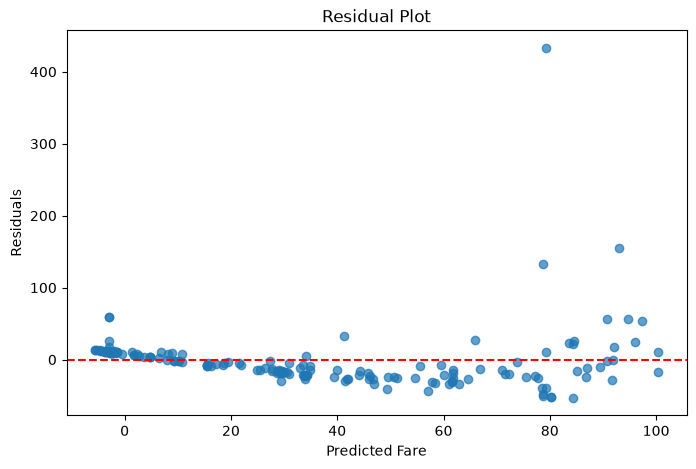

In [42]:
residuals = y_test_reg - y_pred

plt.figure(figsize=(8,5))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [43]:
joblib.dump(
    best_rf,
    "models/best_pipeline.joblib"
)

print("Model Saved Successfully!")

Model Saved Successfully!


In [44]:
loaded_model = joblib.load(
    "models/best_pipeline.joblib"
)

print("Model Loaded Successfully!")

Model Loaded Successfully!


In [45]:
loaded_prediction = loaded_model.predict(X_test)

loaded_accuracy = accuracy_score(
    y_test,
    loaded_prediction
)

print("Accuracy of Loaded Model :", loaded_accuracy)

Accuracy of Loaded Model : 0.8370786516853933


In [46]:
final_results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Best Random Forest"
    ],

    "Accuracy":[
        results["Logistic Regression"]["Accuracy"],
        results["Decision Tree"]["Accuracy"],
        results["Random Forest"]["Accuracy"],
        best_result["Accuracy"]
    ]

})

final_results.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
3,Best Random Forest,0.837079
2,Random Forest,0.820225
0,Logistic Regression,0.808989
1,Decision Tree,0.769663


In [47]:
print("="*60)
print("PROJECT COMPLETED")
print("="*60)

print("\nBest Classification Model :", best_model_name)

print("Accuracy :", best_result["Accuracy"])

print("Regression R² :", r2)

print("\nPipeline saved successfully.")

PROJECT COMPLETED

Best Classification Model : Random Forest
Accuracy : 0.8370786516853933
Regression R² : 0.34677389181134044

Pipeline saved successfully.
